# 1. Introduction
# Durian AI

## Problem Statement

Assessing the quality of Musang King durians requires experience and manual inspection of shell characteristics.

This project explores whether AI can automatically classify Musang King quality from shell images.

The final output predicts one of three categories:

- Good
- Average
- Bad

## 2. Project Workflow

The system consists of three stages:

1. Vision-Language Model Feature Extraction
2. Rule-Based Quality Scoring
3. Deep Learning Image Classification

Pipeline:

Image
↓
Feature Extraction
↓
Quality Scoring
↓
Good / Average / Bad Label
↓
ResNet18 Training
↓
Quality Prediction

## 3. Dataset Creation

The dataset consists of Musang King durian images.

As the images did not contain quality labels, a Vision-Language Model was used to analyse visible shell characteristics including:

- Shape
- Stem condition
- Shell condition
- Spike condition
- Star-bottom visibility
- Surface cracks

These characteristics were converted into quality labels using a rule-based scoring system.

## 4. Feature Extraction Example

For each image, the Vision-Language Model returns structured attributes.

Example:

{
  "shape": "Round",
  "stem": "Fresh",
  "shell": "Clean",
  "spikes": "Firm",
  "star_bottom": "Visible",
  "cracks": "Small/None"
}

## 5. Quality Scoring

Each characteristic contributes to an overall quality score.

| Feature | Condition | Points |
|----------|-----------|---------|
| Shape | Round | +2 |
| Stem | Fresh | +2 |
| Stem | Unknown | +1 |
| Shell | Clean | +2 |
| Spikes | Firm | +2 |
| Star Bottom | Visible | +2 |
| Cracks | Small/None | +2 |

Quality Categories:

- Good: 11–12
- Average: 8–10
- Bad: 0–7

## Label Generation Logic

The extracted features are converted into a final quality label.

Example scoring:

Round Shape = 2
Fresh Stem = 2
Clean Shell = 2
Firm Spikes = 2
Visible Star Bottom = 2
Small/No Cracks = 2

Total Score = 12

Quality = Good

In [ ]:
def grade(score):
    if score >= 11:
        return "Good"
    elif score >= 8:
        return "Average"
    else:
        return "Bad"

# 6. Dataset Overview

## Generated Dataset

After feature extraction and scoring, a labelled dataset was created.

Each image now contains:

- File path
- Extracted shell features
- Quality score
- Final quality category

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("durian_quality_375.csv")
print("Total Images:", len(df))
df.head()
df.sample(5)

Total Images: 373


,filepath,shape,stem,shell,spikes,star_bottom,cracks,score,quality
14,.\durian_d197\20200815_115109.jpg,Round,Fresh,Clean,Firm,Not Visible,Small/None,10,Average
207,.\durian_d197\20200815_121803.jpg,Irregular,Dry,Clean,Firm,Not Visible,Small/None,6,Bad
20,.\durian_d197\20200815_115153.jpg,Round,Fresh,Clean,Firm,Not Visible,Small/None,10,Average
133,.\durian_d197\20200815_120750 - Copy.jpg,Irregular,Fresh,Clean,Firm,Visible,Small/None,10,Average
228,.\durian_d197\20200815_152244 - Copy.jpg,Irregular,Fresh,Clean,Firm,Not Visible,Small/None,8,Average


## Dataset Distribution

The distribution of generated quality labels is shown below.

In [13]:
df["quality"].value_counts()

quality
Average    260
Good        71
Bad         42
Name: count, dtype: int64

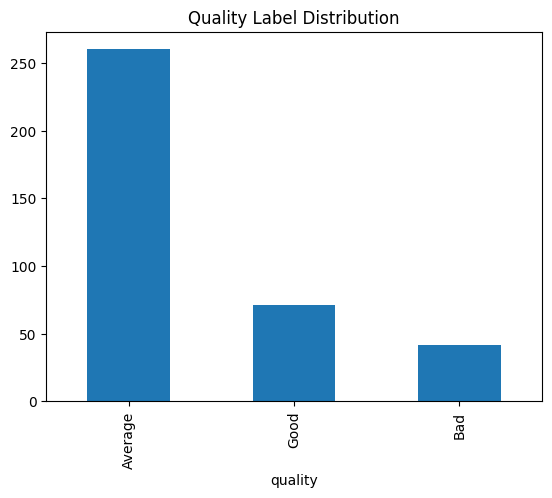

In [15]:
df["quality"].value_counts().plot(kind="bar")
plt.title("Quality Label Distribution")
plt.show()

# 7. Dataset Preparation

In [2]:
import pandas as pd
import os
import shutil
from sklearn.model_selection import train_test_split

df = pd.read_csv("durian_quality_375.csv")

df["filepath"] = (
    df["filepath"]
    .str.replace("\\", "/", regex=False)
    .str.replace("./", "", regex=False)
    .str.replace(".\\", "", regex=False)
)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

for split_name, split_df in [
    ("train", train_df),
    ("val", val_df)
]:

    for _, row in split_df.iterrows():

        quality = row["quality"]

        os.makedirs(
            f"dataset/{split_name}/{quality}",
            exist_ok=True
        )

        src = row["filepath"]

        filename = os.path.basename(src)

        dst = f"dataset/{split_name}/{quality}/{filename}"

        shutil.copy(src, dst)

# 8. Model Setup

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    "dataset/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "dataset/val",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

print(train_dataset.classes)

['Average', 'Bad', 'Good']


## 9. Model Training

A ResNet18 image classification model was trained using the generated labels.

The model learns visual patterns associated with Musang King quality and predicts the final quality category directly from images.

In [5]:
model = models.resnet18(weights="DEFAULT")

model.fc = nn.Linear(
    model.fc.in_features,
    len(train_dataset.classes)
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_

## 11. Training Configuration

Loss Function:
- CrossEntropyLoss

Optimizer:
- Adam

Learning Rate:
- 0.001

Epochs:
- 5

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {running_loss:.4f}"
    )

Epoch 1/5 Loss: 84.7994
Epoch 2/5 Loss: 68.8489
Epoch 3/5 Loss: 62.2191
Epoch 4/5 Loss: 63.4781
Epoch 5/5 Loss: 64.3216


## 12. Model Evaluation

The trained model was evaluated using a validation dataset to measure its ability to classify unseen Musang King images.

In [7]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 74.03%


In [8]:
torch.save(
    model.state_dict(),
    "durian_model.pth"
)

print("Model saved")

Model saved


## 13. Sample Prediction

The trained model can predict the quality category of a new Musang King image.

Example output:

Predicted Quality: Average

In [9]:
from PIL import Image
import torch

img = Image.open(
    "durian_d197/20200815_114839.jpg"
).convert("RGB")

img = transform(img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(img)

pred = torch.argmax(output, 1).item()

print(
    train_dataset.classes[pred]
)

Average


## 14. Results

The model successfully learned visual patterns associated with Musang King shell characteristics.

Key achievements:

- Generated labels from previously unlabeled images
- Automated quality scoring using domain-inspired rules
- Trained a ResNet18 classifier on generated labels
- Predicted quality categories directly from shell images

This demonstrates the feasibility of AI-assisted Musang King quality assessment.

## 15. Conclusion

This project demonstrates an end-to-end AI pipeline for Musang King quality assessment.

Starting from unlabeled images, a Vision-Language Model extracted shell characteristics which were converted into quality labels through a rule-based scoring system.

These generated labels were then used to train a ResNet18 classifier capable of predicting quality categories directly from images.

The approach significantly reduces manual labeling effort while providing a foundation for future AI-assisted durian grading systems.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=bb84e47c-77e2-4334-b1ea-24c81466612b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>